In [1]:
! pip install -U hilearn --no-dependencies

  Using cached hilearn-0.2.2.tar.gz (539 kB)
  Preparing metadata (setup.py) ... done
  Created wheel for hilearn: filename=hilearn-0.2.2-py3-none-any.whl size=20894 sha256=be5b85020043ee43088ca707ae17a39a96dedfd86bdfe28ae34124324e8dc421
  Stored in directory: /home/r20user3/.cache/pip/wheels/6e/5d/f3/bb294d5e0cef9b139f8d5a7403a88e9de53650d9649db8693a
Successfully built hilearn


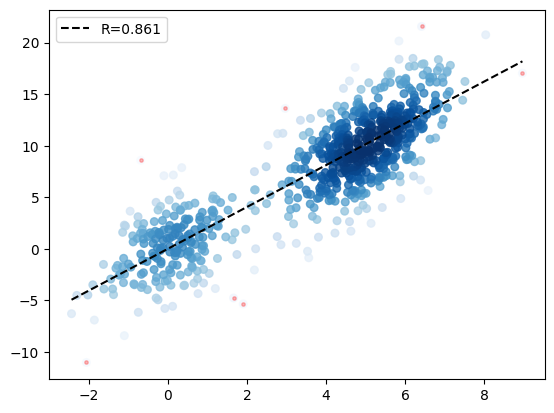

In [3]:
import numpy as np
from hilearn.plot import corr_plot
np.random.seed(1)
x = np.append(np.random.normal(size=200), 5 + np.random.normal(size=500))
y = 2 * x + 3 * np.random.normal(size=700)
corr_plot(x, y)

In [1]:
from glob import glob
tif_list = glob('/data1/r20user3/shared_project/Hist2Cell/code/training/train_test_splits/humanlung_cell2location/test*')
tif_list.sort()
test_slides = list()
for tif in tif_list:
    tif_path = tif.split('_')[-1].split('.')[0]
    test_slides.append(tif_path)
test_slides

['A37', 'A42', 'A48', 'A50']

In [14]:
import joblib
import pandas as pd
import os
import matplotlib.pyplot as plt

cell_names = [cell[23:] for cell in list(pd.read_csv("/data1/r20user3/shared_project/Hist2Cell/data/human_lung_cell2location/WSA_LngSP8759311/cell_ratio.csv").columns)[1:]]
for case in test_slides:
    os.mkdir(os.path.join("/data1/r20user3/shared_project/Hist2Cell/code/analysis/pearson_analysis/pearson_corr_plot_each_case_humanlung", case))
    
    save_path = "/data1/r20user3/shared_project/Hist2Cell/code/analysis/inference/humanlung/humanlung_epoch100_lr1e-4_2hop_ensemble_onlycell_"+case+"_best_cell_all_abundance_average.pkl"
    pred_and_label = joblib.load(save_path)
    
    case_pred = list()
    case_label = list()
    
    for slide in pred_and_label:
        os.mkdir(os.path.join("/data1/r20user3/shared_project/Hist2Cell/code/analysis/pearson_analysis/pearson_corr_plot_each_case_humanlung", case, slide))
        
        pred_and_label[slide]['cell_abundance_predictions'] = np.clip(pred_and_label[slide]['cell_abundance_predictions'], a_min=0, a_max=None)
        pred_ratio = pred_and_label[slide]['cell_abundance_predictions'] / pred_and_label[slide]['cell_abundance_predictions'].sum(axis=1, keepdims=True)
        real_ratio = pred_and_label[slide]['cell_abundance_labels'] / pred_and_label[slide]['cell_abundance_labels'].sum(axis=1, keepdims=True)
        
        os.mkdir(os.path.join("/data1/r20user3/shared_project/Hist2Cell/code/analysis/pearson_analysis/pearson_corr_plot_each_case_humanlung", case, slide, "cell proportion"))
        for i in range(80):
            plt.figure(figsize=(4, 4))
            x = np.squeeze(pred_ratio[:,[i]])
            y = np.squeeze(real_ratio[:,[i]])

            corr_plot(x, y)
            plt.title(cell_names[i])
            plt.xlabel("Inferred cell proportion")
            plt.ylabel("Cell2location cell proportion")
            # plt.show()
            plt.savefig(os.path.join("/data1/r20user3/shared_project/Hist2Cell/code/analysis/pearson_analysis/pearson_corr_plot_each_case_humanlung", case, slide, "cell proportion", cell_names[i]+".png"))
            plt.close()

            
        os.mkdir(os.path.join("/data1/r20user3/shared_project/Hist2Cell/code/analysis/pearson_analysis/pearson_corr_plot_each_case_humanlung", case, slide, "cell abundance"))
        for i in range(80):
            plt.figure(figsize=(4, 4))
            x = np.squeeze(pred_and_label[slide]['cell_abundance_predictions'][:,[i]])
            y = np.squeeze(pred_and_label[slide]['cell_abundance_labels'][:,[i]])

            corr_plot(x, y)
            plt.title(cell_names[i])
            plt.xlabel("Inferred cell abundance")
            plt.ylabel("Cell2location cell abundance")
            # plt.show()
            plt.savefig(os.path.join("/data1/r20user3/shared_project/Hist2Cell/code/analysis/pearson_analysis/pearson_corr_plot_each_case_humanlung", case, slide, "cell abundance", cell_names[i]+".png"))
            plt.close()
        
        case_pred.append(pred_and_label[slide]['cell_abundance_predictions'])
        case_label.append(pred_and_label[slide]['cell_abundance_labels'])
    
    case_pred = np.concatenate(case_pred)
    case_label = np.concatenate(case_label)
    pred_ratio = case_pred / case_pred.sum(axis=1, keepdims=True)
    real_ratio = case_label / case_label.sum(axis=1, keepdims=True)
    os.mkdir(os.path.join("/data1/r20user3/shared_project/Hist2Cell/code/analysis/pearson_analysis/pearson_corr_plot_each_case_humanlung", case, "cell proportion"))
    for i in range(80):
        plt.figure(figsize=(4, 4))
        x = np.squeeze(pred_ratio[:,[i]])
        y = np.squeeze(real_ratio[:,[i]])

        corr_plot(x, y)
        plt.title(cell_names[i])
        plt.xlabel("Inferred cell proportion")
        plt.ylabel("Cell2location cell proportion")
        # plt.show()
        plt.savefig(os.path.join("/data1/r20user3/shared_project/Hist2Cell/code/analysis/pearson_analysis/pearson_corr_plot_each_case_humanlung", case, "cell proportion", cell_names[i]+".png"))
        plt.close()

        
    os.mkdir(os.path.join("/data1/r20user3/shared_project/Hist2Cell/code/analysis/pearson_analysis/pearson_corr_plot_each_case_humanlung", case, "cell abundance"))
    for i in range(80):
        plt.figure(figsize=(4, 4))
        x = np.squeeze(case_pred[:,[i]])
        y = np.squeeze(case_label[:,[i]])

        corr_plot(x, y)
        plt.title(cell_names[i])
        plt.xlabel("Inferred cell proportion")
        plt.ylabel("Cell2location cell proportion")
        # plt.show()
        plt.savefig(os.path.join("/data1/r20user3/shared_project/Hist2Cell/code/analysis/pearson_analysis/pearson_corr_plot_each_case_humanlung", case, "cell abundance", cell_names[i]+".png"))
        plt.close()